### Simulation Investigation into Conditional Trend Filtering and Changepoint Detection on High-Frequency Price Process

Jason Bohne

Jason.bohne@stonybrook.edu

Applied Math and Stats Ph.D. Student 

Under Supervision of Professor Pawel Polak



In [31]:
import sys
import numpy as np
from collections import deque
import pandas as pd
import matplotlib.pyplot as plt


path='/home/jbohn/jupyter/personal/'
sys.path.append(f'{path}TAQ-Query-Scripts/data')
sys.path.append(f'{path}Changepoint_LOB/Lasso/CPD')

from kernel_smoother import smooth_series, cv_block_size, mom_kde
from adaptive_tf_ir import l1tf_adaptive_ir, Dmat,compute_lambda_max, sparse_inversion

### Prep Data

- First minute seconds of trade data for AAPL after open across availble U.S. equity exchanges
- Benchmark model for seconds however can extend to any time interval
- Group observations by participant side timestamp; averaging price and summing volume
- Results in ~1400 observations
- Preprocessed and cleaned to remove trades executed before open

In [2]:
trades=pd.read_csv(f'{path}TAQ-Query-Scripts/data/cleaned_trades.csv',index_col=0).dropna()
trades=trades[trades.index < "2020-01-02 09:41:00"]
trades=trades[trades.index> "2020-01-02 09:40:00"]
trades.index=pd.to_datetime(trades.index)
trades['Index']=trades.index
trades=trades.groupby('Index').agg({'Trade_Price':np.mean, 'Trade_Volume':np.sum})


trades['Trade_Price']=np.log(trades['Trade_Price'])
trades=trades[trades['Trade_Volume']<1000]




### Hyperparameters
- Prior Series $X_T$
- Number of Local Max; N
- Stationary Variance $\sigma^2$

In [3]:
N=20
variance=10e-5
sample_variance=0.005

### Step 1; Generate Prior & Smooth

- In our analysis trade volume will be used as a prior for changes in underlying price trend however any discrete series can be utilized (realized volatility)
- Normalize time of prior to be incremented in total seconds

In [4]:
original_index=trades['Trade_Volume'].index
volume_index=[(i -original_index[0]).total_seconds() for i in original_index]
volume_prior=trades['Trade_Volume'].values

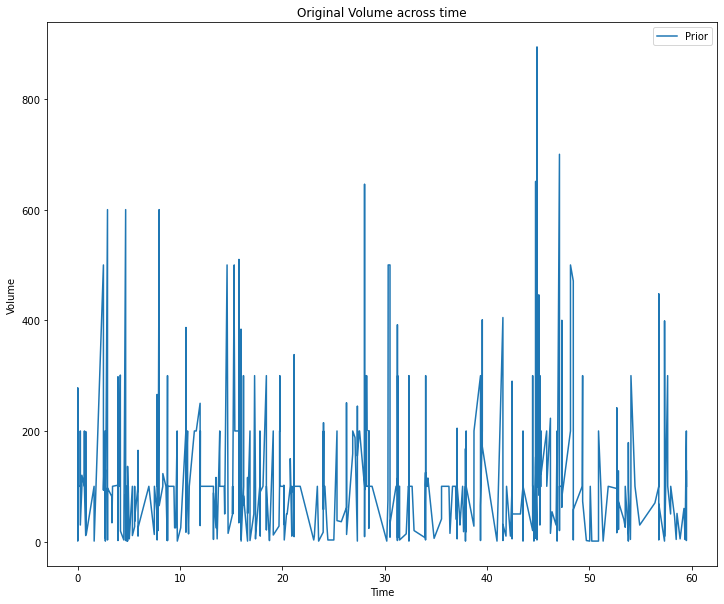

In [5]:
fig,ax=plt.subplots(figsize=(12,10))
plt.title("Original Volume across time")
plt.ylabel("Volume")
plt.xlabel("Time")
plt.plot(volume_index,volume_prior,label="Prior")
plt.legend()

In [6]:
smooth_volume,bw=smooth_series(volume_prior,volume_index)

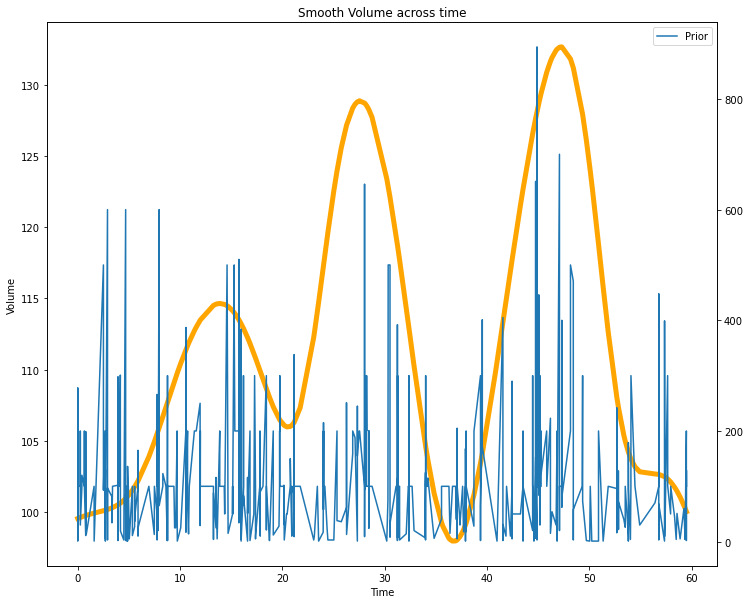

In [7]:
fig,ax=plt.subplots(figsize=(12,10))
plt.title("Smooth Volume across time")
plt.ylabel("Volume")
plt.xlabel("Time")
ax.plot(volume_index,smooth_volume,label="Smooth",color='orange',lw=5)
ax2=ax.twinx()
ax2.plot(volume_index,volume_prior,label="Prior")
plt.legend()

### Step 2; Identify spikes in volume 
- Assumes changes in underlying trend occur within some d- neighborhood here
- Such that d is a hyperparameter prespecified

In [10]:
def remove_consecutive_max(indices,values,d):
 
    tuples=[(i,i+1) for i in range(0,len(indices))]

    diff_dict=dict(zip(tuples,np.diff(indices)))
    diff_list=sorted(diff_dict.items(),key=lambda x:x[1])
    list_indices=[i[0] for i in diff_list if i[1]<d]
    remove_indices=[i[np.argmin(np.array([values[i[0]-1],values[i[1]-1]]))] for i in list_indices]
    
    indices_to_keep=np.setdiff1d(np.arange(0,len(indices),1),remove_indices)
    
    return indices_to_keep


def find_max(prior,count,d=None):
    """ Find max n values of a series constrained to have certain distance d
    """
    
    if d is None:
        d=np.floor(0.01*len(prior))
        
    series=dict(zip(np.arange(0,len(prior)),prior))
    sorted_series=sorted( series.items(), key=lambda x:x[1],reverse=True)[:count]
    sorted_series=sorted(sorted_series, key=lambda x:x[0])
    
    indices=np.array([i[0] for i in sorted_series])
    values=np.array([i[1] for i in sorted_series])
    
    
    indices_to_keep=remove_consecutive_max(indices,values,d)
    
    new_indices=indices[indices_to_keep]
    new_values=values[indices_to_keep]
    
    return new_indices,new_values
    
indices,values=find_max(volume_prior,N)
indices

array([ 49,  64,  96, 147, 245, 256, 391, 400, 456, 674, 711, 724, 783])

### Step 3 ; Generate True Underlying Trend

- Given identified max values iterate forward at some linear rate
- Each change in underlying series is sampled from a normal distribution of variance prespecified 
- Interpretation is that most consecutive values will be piecewise linear with small noise; with sparse jumps arising from larger variance 


In [11]:
def generate_true_underlying(changepoints,variance,prior,prior_index=None,init=0,threshold=1,seed=1223224):
    """ Simulate price process as piecewise linear between selected changepoints; scaling distance btwn consecutive cp
    """
    np.random.seed(seed)
    if prior_index is None:
        prior_index=np.ones(len(prior))
    
    #soft thresholding to 1
    prior_index=np.fmax(prior_index,1)
    
    
    x0=0
    N=len(prior)
    samples=[]
    samples.append(x0)
    init_step=np.random.normal(loc=0,scale=variance,size=1)[0]
    
    samples.append(x0+init_step)
    prev_timestep=prior_index[0]
     
    for point in range(2,N):
        time_step=prior_index[point-1]
        mu=samples[point-1]+time_step*(samples[point-1]-samples[point-2]) # timesteps cancel out iteratively; better formulation numerically 
        
        # indicator function
        indicator=np.isin(point-1,changepoints).astype(int) # lagged cp
        scale=variance*indicator*time_step
        
        sample=mu+np.random.normal(loc=0,scale=scale,size=1)[0]
    
        samples.append(sample)
        prev_timestep=time_step
   

    return np.array(samples)+init

In [12]:
true_series=generate_true_underlying(indices,variance,volume_prior,init=50)

Text(0.5, 1.0, 'Simulated True Price Process')

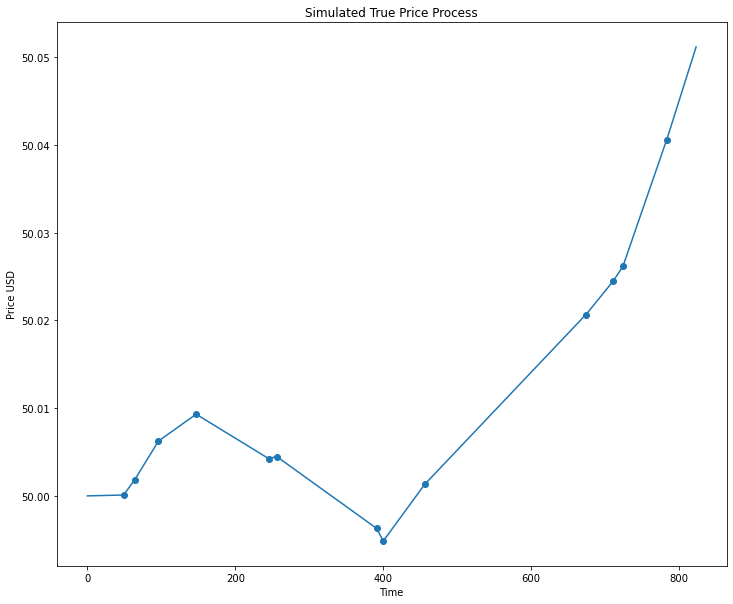

In [13]:
fig,ax=plt.subplots(figsize=(12,10))
plt.plot(true_series)
plt.scatter(indices,true_series[indices])
plt.xlabel("Time")
plt.ylabel("Price USD")
plt.title("Simulated True Price Process")

### Step 4;  Generate normal sample of discrete process with centered locaiton parameters and prespecified variance parameter

In [14]:
def sample_discrete_process(true_series,sample_variance,seed=1223224):
    np.random.seed(seed)
    def generate_normal(mu,variance):
        return np.random.normal (loc=mu,scale=sample_variance,size=1)[0]
    
    samples=[generate_normal(mu,sample_variance) for mu in true_series]
    
    return np.array(samples)

x_i=sample_discrete_process(true_series,sample_variance)

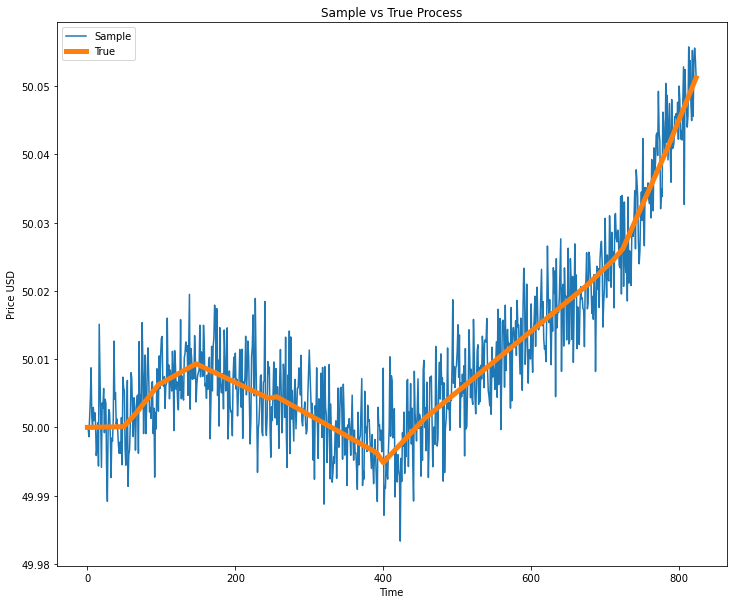

In [15]:
fig,ax=plt.subplots(figsize=(12,10))
plt.plot(x_i,label='Sample')
plt.plot(true_series,label='True',lw=5)
plt.xlabel("Time")
plt.ylabel("Price USD")
plt.title("Sample vs True Process")
plt.legend()

### Numerical Results 1; L1 trend filtering 

- Given the simulated path from step 5; we wish to apply L1 trend filtering to the problem
- Incorporates irregular spacing between observations
- Constrains our estimator to be piecewise linear 
- Here constant penalty is chosen off grid search

In [33]:
lambda_max=compute_lambda_max(x_i.reshape(-1,1))

lambda_grid=np.linspace(0,lambda_max,10)

334690959618.8125

In [12]:
trend_filter_series,status,D=l1tf_adaptive_ir(x_i.reshape(-1,1),t=volume_index,lambda_p=50)


pobj1: [[7.14942681e+09]], pobj2: [[36279554.72065337]], dobj: [[0.]], gap: [[36279554.72065337]]
pobj1: [[1.3187485e+10]], pobj2: [[0.18879026]], dobj: [[0.01081342]], gap: [[0.17797685]]
solved
pobj1: [[367613.24855352]], pobj2: [[0.03713685]], dobj: [[0.03278185]], gap: [[0.004355]]


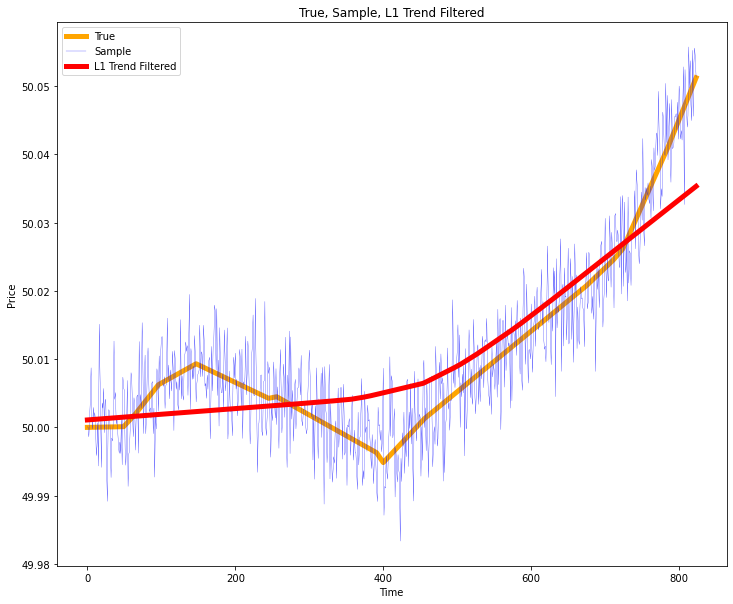

In [13]:
fig,ax=plt.subplots(figsize=(12,10))
plt.plot(true_series,label='True', lw=5,color='orange')
plt.plot(x_i,label='Sample',color='blue',lw=0.25)
plt.plot(trend_filter_series,label='L1 Trend Filtered',lw=5,color='red')
plt.title("True, Sample, L1 Trend Filtered")
plt.xlabel("Time")
plt.ylabel('Price')
plt.legend()

### Numerical Result 1; Conditional Adaptive L1 trend filtering  
- Estimator is piecewise linear accounting for irregular observations
- Sensitivity of estimator to changes in underlying trend is conditional on inverse of prior 
- Included explicitly as adaptive penalty (scaled by scale_factor)

In [14]:
scale_factor=100 # scale from optimal cv of constant penalty 

adaptive_trend_filter_series,status,D=l1tf_adaptive_ir(x_i.reshape(-1,1),t=volume_index,lambda_p=scale_factor*1/volume_prior[1:-1])
adaptive_trend_filter_series=adaptive_trend_filter_series.reshape(1,-1)[0][1:-1]

pobj1: [[1.59032628e+09]], pobj2: [[7341559.89809235]], dobj: [[0.]], gap: [[7341559.89809235]]
pobj1: [[3.67698477e+11]], pobj2: [[0.03755977]], dobj: [[0.00953904]], gap: [[0.02802074]]
solved
pobj1: [[2.02239235e+10]], pobj2: [[0.01654187]], dobj: [[0.00980895]], gap: [[0.00673292]]


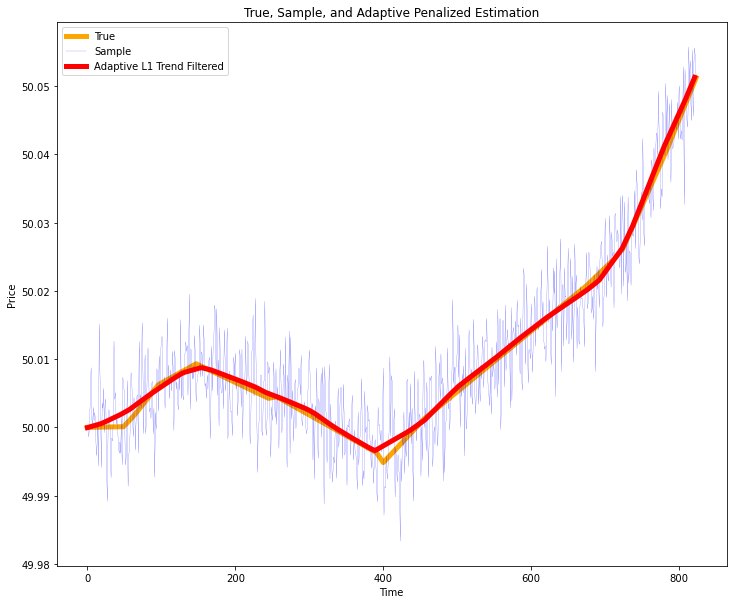

In [15]:
fig,ax=plt.subplots(figsize=(12,10))
plt.plot(true_series,label='True', lw=5,color='orange')
plt.plot(x_i,label='Sample',color='blue',lw=0.15)
plt.plot(adaptive_trend_filter_series,label='Adaptive L1 Trend Filtered',lw=5,color='red')
plt.title("True, Sample, and Adaptive Penalized Estimation")
plt.xlabel("Time")
plt.ylabel('Price')
plt.legend()

### Step 7; Changepoint Extraction

- As estimator is piecweise linear; changepoints can be recovered in both simulations with second order difference operator
- Recovered changepoints plotted below; marked in black
- Threshold for occurrence of changepoint is another hyperparameter to be tuned

In [16]:
def extract_cp(smooth,difference_order=2,threshold=1e-6):
    """ Extract changepoints via difference operator 
    """
    diff_mat=Dmat(len(smooth),2).todense()
    diff=np.dot(diff_mat,smooth).reshape(1,-1)[0]
    
    x,y,index=np.where([abs(diff)>threshold])
    return index

In [17]:
changepoints=extract_cp(trend_filter_series)
adaptive_changepoints=extract_cp(adaptive_trend_filter_series,threshold=1e-4)

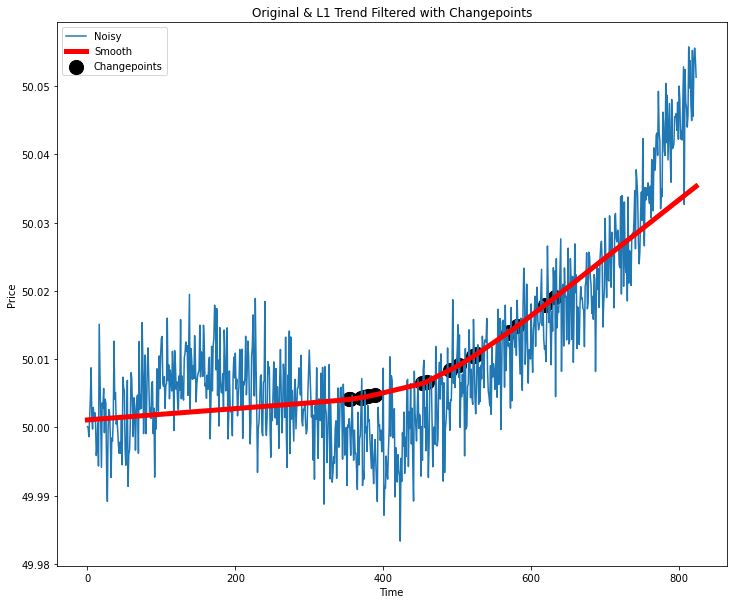

In [18]:
fig,ax=plt.subplots(figsize=(12,10))
plt.plot(x_i,label='Noisy')
plt.plot(trend_filter_series,label='Smooth',lw=5,color='red')
plt.scatter(np.arange(0,len(x_i),1)[changepoints],trend_filter_series[changepoints],color='black',s=200,label='Changepoints')
plt.title("Original & L1 Trend Filtered with Changepoints")
plt.xlabel("Time")
plt.ylabel('Price')
plt.legend()

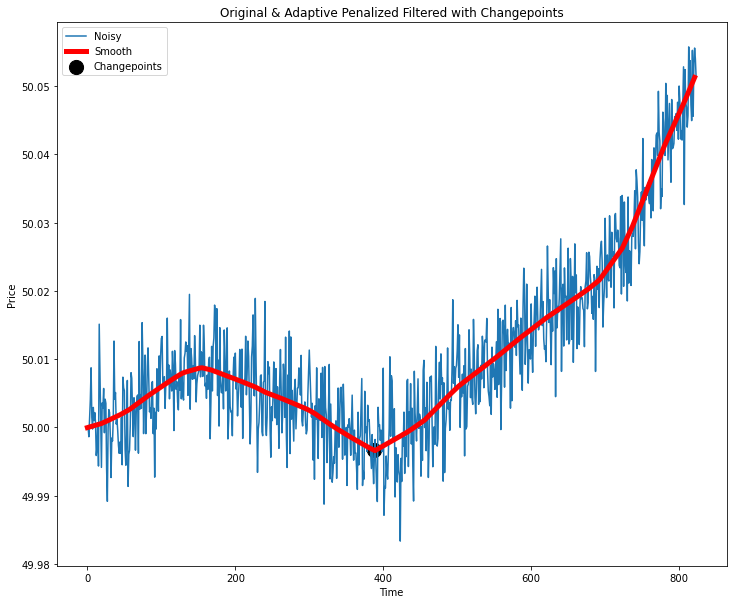

In [19]:
fig,ax=plt.subplots(figsize=(12,10))
plt.plot(x_i,label='Noisy')
plt.plot(adaptive_trend_filter_series,label='Smooth',lw=5,color='red')
plt.scatter(np.arange(0,len(x_i),1)[adaptive_changepoints],adaptive_trend_filter_series[adaptive_changepoints],color='black',s=200,label='Changepoints')
plt.title("Original & Adaptive Penalized Filtered with Changepoints")
plt.xlabel("Time")
plt.ylabel('Price')
plt.legend()

### Instability in Time

Visualizing against true time increments

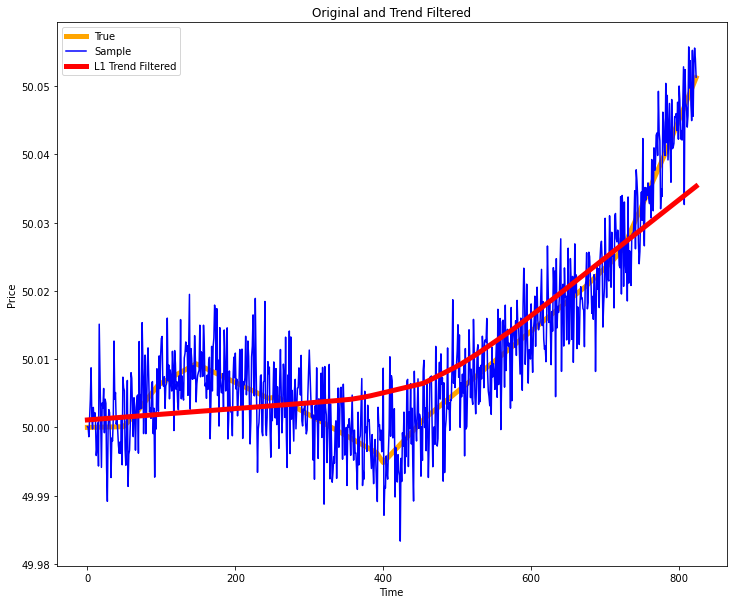

In [20]:
fig,ax=plt.subplots(figsize=(12,10))
plt.plot(true_series,label='True', lw=5,color='orange')
plt.plot(x_i,label='Sample',color='blue')
plt.plot(trend_filter_series,label='L1 Trend Filtered',lw=5,color='red')
plt.title("Original and Trend Filtered")
plt.xlabel("Time")
plt.ylabel('Price')
plt.legend()

### Passing in original time increments

Generate true signal assuming time increments; thresholding internally for numerical stability

In [21]:
diff_index=np.diff(volume_index)
concat_index=np.append(diff_index,np.mean(diff_index))

time_spaced_series=generate_true_underlying(indices,variance,volume_prior,concat_index,init=50)


Text(0.5, 1.0, 'Simulated Path off True Time Steps')

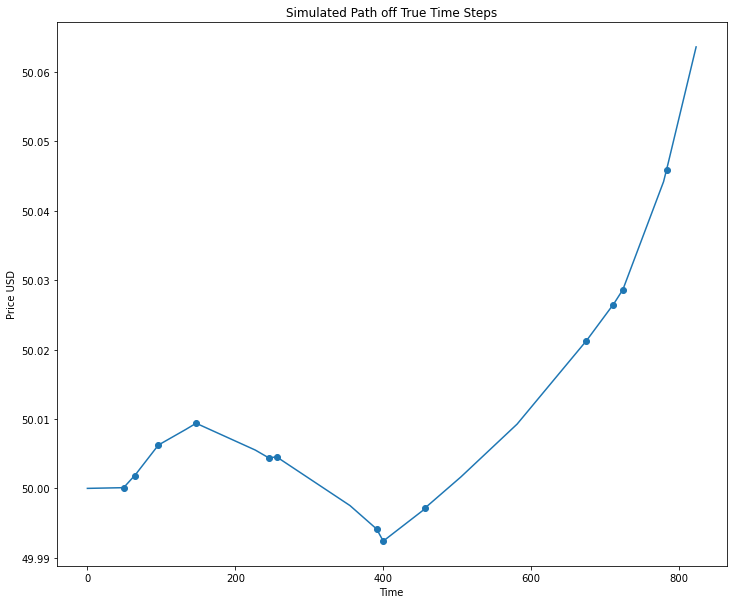

In [28]:
fig,ax=plt.subplots(figsize=(12,10))
plt.plot(time_spaced_series)
plt.scatter(indices,time_spaced_series[indices])
plt.xlabel("Time")
plt.ylabel("Price USD")
plt.title("Simulated Path off True Time Steps")

In [23]:
x_i_time=sample_discrete_process(time_spaced_series,sample_variance)

Text(0.5, 1.0, 'Simulated Path')

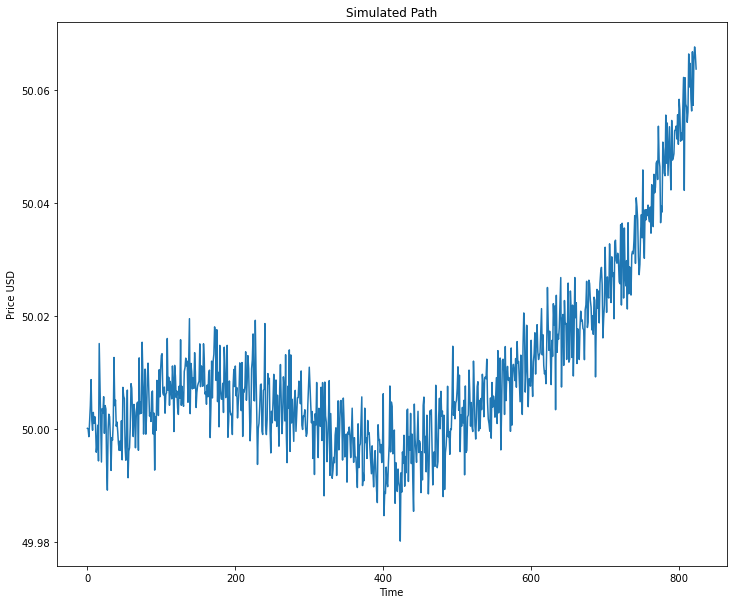

In [24]:
fig,ax=plt.subplots(figsize=(12,10))
plt.plot(x_i_time)
plt.xlabel("Time")
plt.ylabel("Price USD")
plt.title("Simulated Path")

In [25]:
trend_filter_series_time,status,D=l1tf_adaptive_ir(x_i_time.reshape(-1,1),t=volume_index,lambda_p=50)

pobj1: [[7.16433597e+09]], pobj2: [[36279422.67964351]], dobj: [[0.]], gap: [[36279422.67964351]]
pobj1: [[1.32590634e+10]], pobj2: [[0.22868137]], dobj: [[0.01117717]], gap: [[0.2175042]]
solved
pobj1: [[3516154.00588324]], pobj2: [[0.04912454]], dobj: [[0.04368916]], gap: [[0.00543538]]


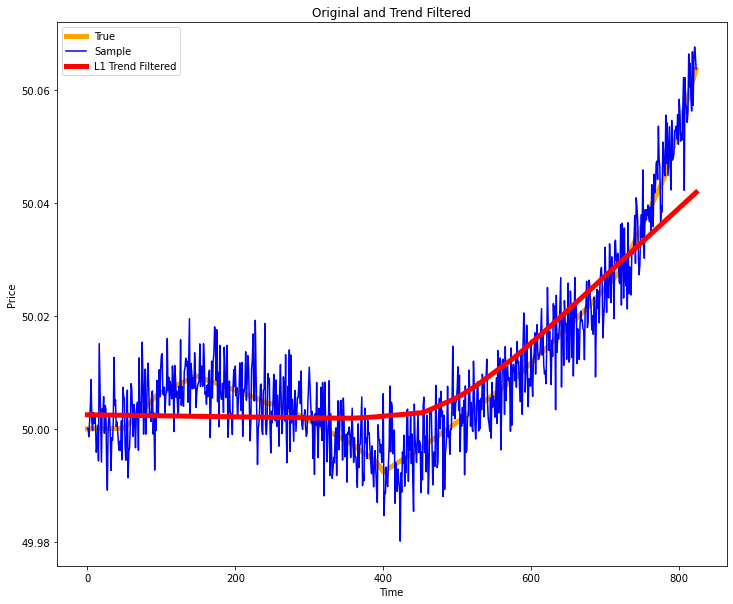

In [26]:
fig,ax=plt.subplots(figsize=(12,10))
plt.plot(time_spaced_series,label='True', lw=5,color='orange')
plt.plot(x_i_time,label='Sample',color='blue')
plt.plot(trend_filter_series_time,label='L1 Trend Filtered',lw=5,color='red')
plt.title("Original and Trend Filtered")
plt.xlabel("Time")
plt.ylabel('Price')
plt.legend()